# Attention for Vietnamese text summarization — VNDS

**Task:** abstractive summarization. Given a news article, write its abstract.

**Dataset:** [VNDS / vietnews](https://huggingface.co/datasets/nam194/vietnews) — 143,816
Vietnamese news articles paired with a human-written abstract, already word-segmented
(`khởi_tố`, `ma_tuý`). From *VNDS: A Vietnamese Dataset for Summarization*, Nguyen et al., 2019.

**What this notebook does.** It builds the same GRU encoder–decoder **twice**:

| | The decoder sees |
|---|---|
| **A. no attention** | one fixed vector — the encoder's final state |
| **B. + attention** | every encoder position, re-weighted at each output step |

Everything else is held identical, so the difference in ROUGE is the value of attention and
nothing else. The attention layer is written out by hand rather than imported, because that is
the point of the exercise.

### To run on Kaggle

1. **Settings → Accelerator → GPU T4.** One is enough — see the next section.
2. **Settings → Internet → On.** The data is fetched from HuggingFace; without internet the
   download cell fails with a clear message.
3. Run all. About 25 minutes end to end at the defaults.

**Scale:** these are demo defaults — 15,000 of the 99,134 training articles, each truncated to 256
tokens. Enough to show the pipeline works and to measure the attention gap honestly; not a serious
summarization system. `N_TRAIN` is the one knob that changes that.

## Why one GPU and float32

The previous project in this repo (`260106_SequentialModel`) ran on Kaggle's **T4 ×2** with
`MirroredStrategy` and measured what the second GPU is actually worth: **1.6–1.9×, not 2×** — the
gap is the per-step gradient all-reduce. The models here are far smaller and each trains in about
five minutes, so:

- **One GPU.** At this size the sync overhead is a bigger share of each step, and five minutes does
  not need halving. The bottleneck in this notebook is not the GPU at all.
- **float32.** `mixed_float16` was the large lever in the LSTM project because a `Dense(20000)`
  over 100 timesteps dominated its FLOPs. Here that layer runs over 63 timesteps at batch 32, which
  fp32 handles in roughly 15 s/epoch.

fp16 also has a hazard specific to attention. Masking padded positions works by adding a large
negative number to their scores before the softmax — and **`-1e9` is `-inf` in fp16**, whose
maximum is 65504. `-inf` in a softmax gives NaN, and the symptom is a loss that turns to NaN with
nothing obviously wrong in the model. The attention layers below compute their scores in float32
for exactly this reason, so `MIXED_PRECISION = True` is safe if you want it.

In [4]:
import os, re, json, time, math, collections
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

IN_KAGGLE = os.path.isdir("/kaggle/input")
IN_COLAB = "google.colab" in str(globals().get("get_ipython", lambda: "")())

# Kaggle gives every session a writable /kaggle/working; elsewhere keep the files beside the
# notebook. DATA_DIR overrides both, which is what the smoke test below uses.
DATA = Path(os.environ.get("DATA_DIR") or ("/kaggle/working" if IN_KAGGLE else "./data"))
OUT = Path(os.environ.get("OUT_DIR") or ("/kaggle/working" if IN_KAGGLE else "./outputs"))
DATA.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
where = "kaggle" if IN_KAGGLE else "colab" if IN_COLAB else "local"
print(f"tensorflow {tf.__version__} | keras {tf.keras.__version__} | {where}")
print(f"GPU: {[g.name for g in gpus] or 'none — CPU only, expect minutes per epoch'}")

tensorflow 2.20.0 | keras 3.13.2 | kaggle
GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']


## Configuration

Every number the notebook uses sits in this one cell. (When this project is turned into a
repository these become `config/config.yaml` — nothing below is repeated further down.)

In [5]:
SEED = 42

# -- data ---------------------------------------------------------------------------------
N_TRAIN, N_VAL, N_TEST = 15_000, 1_500, 1_000   # of 99,134 / 22,184 / 22,498 available
MAX_ARTICLE = 256        # tokens kept from the start of the article
MAX_SUMMARY = 64         # tokens of the abstract, including <bos> and <eos>
VOCAB_SIZE = 20_000

# -- model --------------------------------------------------------------------------------
EMBED_DIM = 128          # shared by encoder and decoder -- one language, one vocabulary
UNITS = 256              # GRU width, identical in both models
ATTN_UNITS = 64          # width of the additive-attention scoring layer

# -- training -----------------------------------------------------------------------------
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 3
MIXED_PRECISION = False  # see "Why one GPU and float32" above

# -- decoding -----------------------------------------------------------------------------
BLOCK_NGRAM = 3          # never repeat an n-gram of this size; 0 disables it
EVAL_BATCH = 128

# -- what to train ------------------------------------------------------------------------
# The third model swaps only the score function, additive -> scaled dot-product. It costs one
# extra five-minute run and it is the bridge to the Transformer paper. Set False to skip it.
RUN_DOT_PRODUCT = True

# A tiny profile so the whole notebook can be verified on a CPU in a couple of minutes before
# it is trusted with a GPU session. Normal runs never set this.
if os.environ.get("SMOKE_TEST"):
    N_TRAIN, N_VAL, N_TEST = 300, 60, 60
    MAX_ARTICLE, MAX_SUMMARY, VOCAB_SIZE = 64, 24, 2_000
    EMBED_DIM, UNITS, ATTN_UNITS = 32, 48, 32
    BATCH_SIZE, EPOCHS, PATIENCE, EVAL_BATCH = 16, 1, 1, 32
    print("SMOKE TEST — tiny everything, the numbers below mean nothing")

tf.keras.utils.set_random_seed(SEED)
if MIXED_PRECISION and gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("policy:", tf.keras.mixed_precision.global_policy().name)

policy: float32


## 1. The data

The original VNDS release is 150k separate `.txt.seg` files on GitHub, which is painful to fetch.
The `nam194/vietnews` mirror on HuggingFace is the same corpus as three parquet files, needs no
login, and keeps the original word segmentation.

| split | rows |
|---|---|
| train | 99,134 |
| validation | 22,184 |
| test | 22,498 |

Columns: `guid`, `title`, `abstract`, `article`. The abstract is the summarization target; the
title is not used here.

In [6]:
HF = "https://huggingface.co/datasets/nam194/vietnews/resolve/main/data"
PARQUET = {
    "train": "train-00000-of-00001-84acb79f6c6547a5.parquet",
    "validation": "validation-00000-of-00001-210cc51bf3cdb90f.parquet",
    "test": "test-00000-of-00001-123f98d55067eb7b.parquet",
}

def fetch(split):
    """Download one split once, into DATA. Returns the local path."""
    import requests
    dst = DATA / f"vietnews_{split}.parquet"
    if dst.exists():
        return dst
    print(f"downloading {split} ...", end=" ", flush=True)
    try:
        with requests.get(f"{HF}/{PARQUET[split]}", stream=True, timeout=180) as r:
            r.raise_for_status()
            with open(dst, "wb") as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
    except Exception as e:
        dst.unlink(missing_ok=True)
        raise RuntimeError(
            f"could not download {split} ({e}).\n"
            "On Kaggle this is almost always the internet switch: "
            "Settings -> Internet -> On (needs a phone-verified account)."
        ) from e
    print(f"{dst.stat().st_size / 1e6:.0f} MB")
    return dst

def subset(split, n):
    """A random slice, not the first n rows -- `guid` is sequential, so the head of the file is
    one stretch of the crawl rather than a sample of the corpus."""
    df = pd.read_parquet(fetch(split))
    return df.sample(min(n, len(df)), random_state=SEED).reset_index(drop=True)

train_df, val_df, test_df = subset("train", N_TRAIN), subset("validation", N_VAL), subset("test", N_TEST)
print(f"\ntrain {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")

row = train_df.iloc[0]
print(f"\nARTICLE ({len(row.article.split())} tokens)\n  {row.article[:300]} ...")
print(f"\nABSTRACT ({len(row.abstract.split())} tokens)\n  {row.abstract}")


train 15,000 | val 1,500 | test 1,000

ARTICLE (323 tokens)
  Một phương_tiện không người lái của các lực_lượng_vũ_trang Ấn_Độ . Trung_Quốc cho_biết một máy_bay_không_người_lái ( UAV ) của Ấn_Độ đã rơi xuống khu_vực mà quân_đội nước này gọi là " lãnh_thổ Trung_Quốc " nhưng không nêu thời_gian và địa_điểm cụ_thể . " Hành_động của Ấn_Độ đã xâm_phạm chủ_quyền lãn ...

ABSTRACT (21 tokens)
  Bắc_Kinh hôm_nay " phản_đối mạnh_mẽ " New_Delhi vì cho_rằng một UAV của Ấn_Độ đã rơi xuống " lãnh_thổ Trung_Quốc " .


### How long is an article, and how much is lost by truncating it

Attention costs memory in proportion to `article_length × summary_length`, so the input length is
the most expensive number in the notebook. Rather than picking 256 by feel, measure what
truncating actually throws away: what share of the abstract's words still appear in the first *N*
tokens of the article. If the answer barely moves past 256, the rest of the article is mostly not
where the summary comes from.

In [7]:
art_len = train_df.article.str.split().str.len().to_numpy()
sum_len = train_df.abstract.str.split().str.len().to_numpy()

for name, L in (("article", art_len), ("abstract", sum_len)):
    print(f"{name:9} mean {L.mean():5.0f}  median {np.median(L):4.0f}  "
          f"p90 {np.percentile(L, 90):4.0f}  p95 {np.percentile(L, 95):4.0f}  max {L.max():5d}")
print(f"\narticles <= {MAX_ARTICLE} tokens: {(art_len <= MAX_ARTICLE).mean():.1%}")
print(f"abstracts <= {MAX_SUMMARY} tokens: {(sum_len <= MAX_SUMMARY).mean():.1%}")

print("\nshare of abstract words that appear in the first N article tokens:")
probe = train_df.sample(min(2000, len(train_df)), random_state=SEED)
for n in (64, 128, 256, 400, 10**6):
    hits = [
        sum(w in set(a.split()[:n]) for w in s.split()) / max(len(s.split()), 1)
        for a, s in zip(probe.article, probe.abstract)
    ]
    print(f"  first {'all' if n > 10**5 else n:>4}: {np.mean(hits):6.1%}")

article   mean   414  median  356  p90  729  p95  838  max  1832
abstract  mean    28  median   26  p90   40  p95   44  max    90

articles <= 256 tokens: 25.5%
abstracts <= 64 tokens: 99.8%

share of abstract words that appear in the first N article tokens:
  first   64:  46.7%
  first  128:  61.4%
  first  256:  73.4%
  first  400:  77.4%
  first  all:  80.1%


Read the table before moving on. `MAX_ARTICLE = 256` is a real trade, not a default: it keeps most
of what the abstract is made of while cutting the attention matrix roughly in half against the
average article. The gap between 256 and reading the whole article is the ceiling this notebook
gives up.

The same table is also the first hint that **the lead of a Vietnamese news article is most of its
summary** — which is why the baseline below is a serious competitor and not a formality.

## 2. Vocabulary

One shared vocabulary for the article and the abstract: it is the same language, and sharing it
lets a single embedding matrix serve encoder and decoder.

Four reserved ids. `<pad>` is 0 so that padding is never a real word, `<unk>` catches everything
outside the vocabulary, and `<bos>`/`<eos>` tell the decoder where a summary starts and stops —
without `<eos>` the model has no way to say it is finished.

In [8]:
PAD, UNK, BOS, EOS = 0, 1, 2, 3
SPECIALS = ["<pad>", "<unk>", "<bos>", "<eos>"]

counts = collections.Counter()
for article, abstract in zip(train_df.article, train_df.abstract):
    counts.update(article.split()[:MAX_ARTICLE])
    counts.update(abstract.split())

total = sum(counts.values())
ranked = counts.most_common()
print(f"{len(counts):,} distinct words over {total:,} tokens\n")
print("  vocab      covers   <unk>")
for k in sorted({5_000, 10_000, VOCAB_SIZE, 30_000} - {0}):
    if k > len(ranked):
        continue
    covered = sum(n for _, n in ranked[:k]) / total
    mark = "  <-" if k == VOCAB_SIZE else ""
    print(f"  {k:>6,}     {covered:6.2%}  {1 - covered:6.2%}{mark}")

itos = SPECIALS + [w for w, _ in ranked[: VOCAB_SIZE - len(SPECIALS)]]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB = len(itos)
print(f"\nvocabulary {VOCAB:,}; most common words: {itos[4:16]}")

81,161 distinct words over 4,051,290 tokens

  vocab      covers   <unk>
   5,000     89.91%  10.09%
  10,000     94.44%   5.56%
  20,000     97.24%   2.76%  <-
  30,000     98.30%   1.70%

vocabulary 20,000; most common words: [',', '.', 'và', '"', 'của', 'các', 'đã', 'được', 'trong', 'là', 'có', 'với']


The article is truncated and padded to a fixed `MAX_ARTICLE`; the summary is wrapped in
`<bos> ... <eos>` and padded to `MAX_SUMMARY`. Teacher forcing then splits every summary into two
copies shifted by one: the decoder reads `<bos> w1 w2 ...` and must produce `w1 w2 ... <eos>`.

In [9]:
def encode_article(text):
    ids = [stoi.get(w, UNK) for w in text.split()[:MAX_ARTICLE]]
    return ids + [PAD] * (MAX_ARTICLE - len(ids))

def encode_summary(text):
    ids = [stoi.get(w, UNK) for w in text.split()[: MAX_SUMMARY - 2]]
    ids = [BOS] + ids + [EOS]
    return ids + [PAD] * (MAX_SUMMARY - len(ids))

def encode(df):
    return (np.array([encode_article(a) for a in df.article], np.int32),
            np.array([encode_summary(s) for s in df.abstract], np.int32))

X_train, Y_train = encode(train_df)
X_val, Y_val = encode(val_df)
X_test, Y_test = encode(test_df)
print("articles", X_train.shape, " summaries", Y_train.shape)

unk_rate = (Y_train[Y_train != PAD] == UNK).mean()
print(f"<unk> in the summaries the model must produce: {unk_rate:.2%}")

def make_ds(X, Y, shuffle):
    """((article, decoder_input), decoder_target) -- the target is the input shifted one left."""
    ds = tf.data.Dataset.from_tensor_slices(((X, Y[:, :-1]), Y[:, 1:]))
    if shuffle:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

train_ds, val_ds = make_ds(X_train, Y_train, True), make_ds(X_val, Y_val, False)
(a_b, d_b), t_b = next(iter(train_ds))
print(f"\nbatch: article {a_b.shape}  decoder in {d_b.shape}  target {t_b.shape}")
print("in :", " ".join(itos[i] for i in d_b[0, :10].numpy()))
print("out:", " ".join(itos[i] for i in t_b[0, :10].numpy()))

articles (15000, 256)  summaries (15000, 64)
<unk> in the summaries the model must produce: 2.00%


I0000 00:00:1788584421.331176      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788584421.334364      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



batch: article (32, 256)  decoder in (32, 63)  target (32, 63)
in : <bos> Cựu Tổng_thống <unk> da <unk> , 72 tuổi ,
out: Cựu Tổng_thống <unk> da <unk> , 72 tuổi , đã


## 3. How the result gets measured — ROUGE

ROUGE compares the generated summary with the human one by counting overlap.

| | counts |
|---|---|
| **ROUGE-1** | shared single words — is the summary about the right things |
| **ROUGE-2** | shared word pairs — does it put them together the way a person would |
| **ROUGE-L** | the longest common subsequence — same order, gaps allowed |

All three are reported as F1, which matters more than it sounds: F1 punishes a long summary that
happens to contain the right words. That single fact decides the baseline comparison below.

It is implemented here rather than imported. `rouge-score`'s default tokenizer lowercases and
strips anything non-alphanumeric, which destroys Vietnamese diacritics and the `_` that marks a
segmented compound — `khởi_tố` would become two English-looking fragments. The text here is
already tokenized, so splitting on whitespace is both correct and the whole job.

In [10]:
def ngrams(tokens, n):
    return collections.Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))

def f1(overlap, n_pred, n_ref):
    if overlap == 0:
        return 0.0
    precision, recall = overlap / n_pred, overlap / n_ref
    return 2 * precision * recall / (precision + recall)

def rouge_n(pred, ref, n):
    p, r = ngrams(pred, n), ngrams(ref, n)
    return f1(sum((p & r).values()), max(sum(p.values()), 1), max(sum(r.values()), 1))

def lcs_length(a, b):
    """Longest common subsequence, one row of the table at a time -- O(len(b)) memory."""
    row = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            prev, row[j] = row[j], prev + 1 if x == y else max(row[j], row[j - 1])
    return row[-1]

def rouge_l(pred, ref):
    return f1(lcs_length(pred, ref), max(len(pred), 1), max(len(ref), 1))

def rouge(preds, refs):
    """Mean ROUGE-1/2/L over a list of (prediction, reference) token lists, as percentages."""
    scores = np.array([[rouge_n(p, r, 1), rouge_n(p, r, 2), rouge_l(p, r)]
                       for p, r in zip(preds, refs)])
    return dict(zip(("rouge1", "rouge2", "rougeL"), scores.mean(0) * 100))

# Sanity check: identical text must score 100, disjoint text 0.
assert rouge([["a", "b", "c"]], [["a", "b", "c"]])["rouge1"] == 100.0
assert rouge([["a", "b"]], [["x", "y"]])["rouge1"] == 0.0
print("ROUGE implementation:", {k: round(v, 2) for k, v in
      rouge([["một", "hai", "ba", "bốn"]], [["một", "hai", "năm"]]).items()})

ROUGE implementation: {'rouge1': np.float64(57.14), 'rouge2': np.float64(40.0), 'rougeL': np.float64(57.14)}


### The baseline that has to be beaten

Before any model: just copy the first *n* sentences of the article. For English news this is a
famously hard baseline, and Vietnamese news is written the same way — the lead sentence states the
whole story and the rest elaborates.

Reporting Lead-1, Lead-2 and Lead-3 rather than only the usual Lead-3 costs nothing and shows the
F1 effect directly: more sentences means more overlap but a much longer summary, and F1 charges
for the length.

In [11]:
def sentences(text):
    """VNDS is pre-tokenized, so a sentence ends at a space-separated ' . '."""
    return [s.strip() for s in re.split(r"(?<= \.) ", text) if s.strip()]

refs = [s.split() for s in test_df.abstract]
baselines = {}
for n in (1, 2, 3):
    preds = [" ".join(sentences(a)[:n]).split() for a in test_df.article]
    baselines[f"Lead-{n}"] = rouge(preds, refs)
    length = np.mean([len(p) for p in preds])
    print(f"Lead-{n}:  R1 {baselines[f'Lead-{n}']['rouge1']:5.2f}  "
          f"R2 {baselines[f'Lead-{n}']['rouge2']:5.2f}  "
          f"RL {baselines[f'Lead-{n}']['rougeL']:5.2f}   ({length:.0f} tokens)")
print(f"\nreference abstracts average {np.mean([len(r) for r in refs]):.0f} tokens")

Lead-1:  R1 26.28  R2  8.64  RL 21.18   (29 tokens)
Lead-2:  R1 26.76  R2  9.53  RL 20.10   (59 tokens)
Lead-3:  R1 24.69  R2  9.17  RL 18.07   (86 tokens)

reference abstracts average 29 tokens


## 4. The two models

Both are the same encoder–decoder. An encoder GRU reads the article and produces one hidden state
per position; a decoder GRU writes the summary one token at a time, starting from the encoder's
final state.

**A. Without attention**, that final state is *all* the decoder ever gets. The entire article —
256 tokens — has to fit into 256 numbers, and it has to still be there sixty output steps later.
This is the bottleneck the attention papers were written about.

**B. With attention**, the decoder keeps the encoder's final state as its starting point but, at
every output step, also computes a fresh weighted average of *all* encoder positions:

$$\alpha_{t} = \mathrm{softmax}\big(\mathrm{score}(s_t, h_{1..S})\big), \qquad c_t = \sum_i \alpha_{t,i} h_i$$

The scoring function is the part being implemented. Bahdanau's is additive — a small feed-forward
network over the pair:

$$\mathrm{score}(s_t, h_i) = v^\top \tanh(W_1 h_i + W_2 s_t)$$

**The cost of writing that vectorised is worth seeing.** Scoring every output step against every
input position at once builds a tensor of shape `(batch, summary_len, article_len, attn_units)` —
at 32 × 63 × 256 × 64 that is 33 M floats, 132 MB, and the backward pass wants its own copies. The
dot-product alternative,

$$\mathrm{score}(s_t, h_i) = \frac{s_t \cdot h_i}{\sqrt{d}}$$

is one `matmul` and never leaves `(batch, summary_len, article_len)` — 132× smaller here. That is
precisely the argument *Attention Is All You Need* makes for choosing it (section 3.2.1: *"dot-product
attention is much faster and more space-efficient in practice, since it can be implemented using
highly optimized matrix multiplication code"*), and the `√d` is there because without it large
dimensions push the dot products into the flat tails of the softmax, where gradients vanish.

Both score functions are below; the third training run swaps one for the other.

In [12]:
class AdditiveAttention(tf.keras.layers.Layer):
    """Bahdanau (2015) scoring: v^T tanh(W1 h_i + W2 s_t), one weight per encoder position."""

    # The encoder mask arrives as an explicit argument, not through Keras's mask plumbing.
    # Without this, Keras warns that the layer is "destroying" a mask it was never using.
    supports_masking = True

    def __init__(self, units, **kw):
        super().__init__(**kw)
        self.W1 = tf.keras.layers.Dense(units, use_bias=False)   # over encoder states
        self.W2 = tf.keras.layers.Dense(units, use_bias=False)   # over decoder states
        self.v = tf.keras.layers.Dense(1, use_bias=False)

    def call(self, dec_out, enc_out, enc_mask):
        # dec_out (B, T, H) | enc_out (B, S, H) | enc_mask (B, S) bool, True where real
        keys = self.W1(enc_out)[:, None, :, :]        # (B, 1, S, A)
        queries = self.W2(dec_out)[:, :, None, :]     # (B, T, 1, A)
        scores = tf.squeeze(self.v(tf.tanh(keys + queries)), -1)   # (B, T, S)
        return attend(scores, enc_out, enc_mask)


class DotProductAttention(tf.keras.layers.Layer):
    """Scaled dot-product scoring: (s_t . h_i) / sqrt(d). No parameters at all."""

    supports_masking = True

    def call(self, dec_out, enc_out, enc_mask):
        scores = tf.matmul(dec_out, enc_out, transpose_b=True)     # (B, T, S)
        return attend(scores / math.sqrt(enc_out.shape[-1]), enc_out, enc_mask)


def attend(scores, enc_out, enc_mask):
    """Mask padding, softmax, and take the weighted average of the encoder states.

    The softmax runs in float32 deliberately. Under mixed_float16 the -1e9 used to kill padded
    positions is below fp16's minimum (-65504), so it becomes -inf and the softmax returns NaN.
    """
    scores = tf.cast(scores, tf.float32)
    scores = tf.where(enc_mask[:, None, :], scores, -1e9)
    weights = tf.nn.softmax(scores, axis=-1)                       # (B, T, S)
    context = tf.matmul(tf.cast(weights, enc_out.dtype), enc_out)  # (B, T, H)
    return context, weights

In [13]:
class Seq2Seq(tf.keras.Model):
    """GRU encoder-decoder for summarization, with attention or without it.

    `attention=None` gives model A: the decoder starts from the encoder's final state and never
    sees the article again. Any attention layer gives model B: the same start, plus a fresh
    weighted read of every encoder position at every output step.
    """

    def __init__(self, vocab, attention=None, **kw):
        super().__init__(**kw)
        self.embedding = tf.keras.layers.Embedding(vocab, EMBED_DIM, mask_zero=True)
        self.encoder = tf.keras.layers.GRU(UNITS, return_sequences=True, return_state=True)
        self.decoder = tf.keras.layers.GRU(UNITS, return_sequences=True, return_state=True)
        self.attention = attention
        # Only used with attention: fold [decoder state; context] back to UNITS, so the output
        # layer is the same size in both models and the comparison stays about attention.
        self.combine = tf.keras.layers.Dense(UNITS, activation="tanh") if attention else None
        self.out = tf.keras.layers.Dense(vocab, dtype="float32")

    def encode(self, article):
        enc_out, state = self.encoder(self.embedding(article))
        return enc_out, state

    def decode(self, dec_in, enc_out, state, enc_mask, last_only=False):
        """Returns (logits, attention weights). `last_only` scores just the final position,
        which is all generation needs and skips a Dense over the whole vocabulary per step."""
        dec_out, _ = self.decoder(self.embedding(dec_in), initial_state=state)
        weights = None
        if self.attention is not None:
            context, weights = self.attention(dec_out, enc_out, enc_mask)
            dec_out = self.combine(tf.concat([dec_out, context], axis=-1))
        if last_only:
            dec_out = dec_out[:, -1:, :]
        return self.out(dec_out), weights

    def call(self, inputs):
        article, dec_in = inputs
        enc_out, state = self.encode(article)
        return self.decode(dec_in, enc_out, state, article != PAD)[0]


def build(attention_kind):
    attention = {"none": None,
                 "additive": AdditiveAttention(ATTN_UNITS),
                 "dot": DotProductAttention()}[attention_kind]
    model = Seq2Seq(VOCAB, attention)
    model((a_b, d_b))     # a subclassed model has no shapes until it is called once
    return model

### The loss has to ignore padding

Every summary is padded to 64 tokens, but the average abstract is 28. Score the padding and more
than half the loss is the model being graded on predicting `<pad>` after `<pad>` — which it learns
perfectly, hiding whether it learned anything else. The mask below drops those positions from both
the loss and the accuracy.

The accuracy has to be a `Metric` subclass rather than a function, and the reason is worth
knowing: `mask_zero=True` makes Keras attach the mask to the model's output and pass it to a
function metric as `sample_weight`, which it cannot apply to the single number the function
returned. The failure is a `rank 2 into rank 0` broadcast error at the first step, and it points
at Keras internals rather than at the mask.

`clipnorm=1.0` is not optional for a recurrent model over hundreds of steps: gradients are
multiplied through every step and can grow without bound.

In [14]:
scce = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def masked_loss(y_true, y_pred):
    loss = scce(y_true, y_pred)
    mask = tf.cast(y_true != PAD, loss.dtype)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

class MaskedAccuracy(tf.keras.metrics.Metric):
    """How often the model's top guess is the right token, padding excluded.

    A plain function metric cannot be used here. `Embedding(mask_zero=True)` makes Keras attach a
    (batch, time) mask to the model's output and hand it to the metric as `sample_weight`, which
    it then tries to broadcast onto the scalar the function returned -- a rank-2-into-rank-0
    error at the first training step. A Metric subclass does its own masking and ignores that.
    It is also more correct: totals accumulate across batches instead of averaging per-batch
    means, so a short final batch does not count as much as a full one.
    """

    def __init__(self, name="masked_accuracy", **kw):
        super().__init__(name=name, **kw)
        self.correct = self.add_weight(name="correct", initializer="zeros")
        self.total = self.add_weight(name="total", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        mask = tf.cast(y_true != PAD, tf.float32)
        hit = tf.cast(tf.argmax(y_pred, -1, output_type=y_true.dtype) == y_true, tf.float32)
        self.correct.assign_add(tf.reduce_sum(hit * mask))
        self.total.assign_add(tf.reduce_sum(mask))

    def result(self):
        return self.correct / (self.total + 1e-9)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

def train(name, attention_kind):
    print(f"\n=== {name} ===")
    tf.keras.utils.set_random_seed(SEED)      # same init for every variant
    model = build(attention_kind)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0),
                  loss=masked_loss, metrics=[MaskedAccuracy()])
    print(f"{model.count_params():,} parameters")

    started = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2, shuffle=False,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True)])
    seconds = time.time() - started
    print(f"{seconds / 60:.1f} min, {seconds / len(history.history['loss']):.0f} s/epoch")
    return model, {"history": {k: [float(v) for v in vs] for k, vs in history.history.items()},
                   "params": int(model.count_params()), "train_secs": round(seconds, 1),
                   "epochs_run": len(history.history["loss"])}

## 5. Training

Both models get the same seed, the same batches and the same number of epochs. Early stopping
restores the best weights, so a model that starts overfitting is not punished for it.

In [15]:
models, runs = {}, {}
models["no attention"], runs["no attention"] = train("A. GRU seq2seq, no attention", "none")


=== A. GRU seq2seq, no attention ===
8,292,896 parameters
Epoch 1/15
468/468 - 41s - 88ms/step - loss: 7.1403 - masked_accuracy: 0.0899 - val_loss: 6.5864 - val_masked_accuracy: 0.1136
Epoch 2/15
468/468 - 38s - 81ms/step - loss: 6.2358 - masked_accuracy: 0.1298 - val_loss: 6.0059 - val_masked_accuracy: 0.1447
Epoch 3/15
468/468 - 38s - 82ms/step - loss: 5.6615 - masked_accuracy: 0.1594 - val_loss: 5.6686 - val_masked_accuracy: 0.1677
Epoch 4/15
468/468 - 39s - 83ms/step - loss: 5.2345 - masked_accuracy: 0.1838 - val_loss: 5.4847 - val_masked_accuracy: 0.1782
Epoch 5/15
468/468 - 40s - 85ms/step - loss: 4.8905 - masked_accuracy: 0.2039 - val_loss: 5.3658 - val_masked_accuracy: 0.1888
Epoch 6/15
468/468 - 40s - 85ms/step - loss: 4.5946 - masked_accuracy: 0.2227 - val_loss: 5.2985 - val_masked_accuracy: 0.1951
Epoch 7/15
468/468 - 40s - 85ms/step - loss: 4.3379 - masked_accuracy: 0.2399 - val_loss: 5.2703 - val_masked_accuracy: 0.1982
Epoch 8/15
468/468 - 40s - 85ms/step - loss: 4.1099 

In [16]:
models["additive attention"], runs["additive attention"] = train(
    "B. GRU seq2seq + additive (Bahdanau) attention", "additive")


=== B. GRU seq2seq + additive (Bahdanau) attention ===
8,457,056 parameters
Epoch 1/15
468/468 - 48s - 103ms/step - loss: 7.4758 - masked_accuracy: 0.0408 - val_loss: 7.3276 - val_masked_accuracy: 0.0421
Epoch 2/15
468/468 - 44s - 95ms/step - loss: 7.3305 - masked_accuracy: 0.0475 - val_loss: 7.1709 - val_masked_accuracy: 0.0914
Epoch 3/15
468/468 - 45s - 95ms/step - loss: 6.9527 - masked_accuracy: 0.1031 - val_loss: 6.8001 - val_masked_accuracy: 0.1085
Epoch 4/15
468/468 - 45s - 96ms/step - loss: 6.6213 - masked_accuracy: 0.1152 - val_loss: 6.4868 - val_masked_accuracy: 0.1244
Epoch 5/15
468/468 - 45s - 96ms/step - loss: 6.2285 - masked_accuracy: 0.1354 - val_loss: 6.1140 - val_masked_accuracy: 0.1405
Epoch 6/15
468/468 - 45s - 96ms/step - loss: 5.7643 - masked_accuracy: 0.1588 - val_loss: 5.7676 - val_masked_accuracy: 0.1596
Epoch 7/15
468/468 - 45s - 96ms/step - loss: 5.3408 - masked_accuracy: 0.1827 - val_loss: 5.5320 - val_masked_accuracy: 0.1764
Epoch 8/15
468/468 - 45s - 96ms/s

In [17]:
if RUN_DOT_PRODUCT:
    models["dot-product attention"], runs["dot-product attention"] = train(
        "C. same, scaled dot-product scoring", "dot")


=== C. same, scaled dot-product scoring ===
8,424,224 parameters
Epoch 1/15
468/468 - 43s - 92ms/step - loss: 7.4773 - masked_accuracy: 0.0409 - val_loss: 7.3293 - val_masked_accuracy: 0.0421
Epoch 2/15
468/468 - 40s - 85ms/step - loss: 7.3516 - masked_accuracy: 0.0406 - val_loss: 7.3311 - val_masked_accuracy: 0.0421
Epoch 3/15
468/468 - 40s - 85ms/step - loss: 7.3521 - masked_accuracy: 0.0406 - val_loss: 7.3370 - val_masked_accuracy: 0.0421
Epoch 4/15
468/468 - 40s - 86ms/step - loss: 7.0281 - masked_accuracy: 0.0861 - val_loss: 6.6779 - val_masked_accuracy: 0.1149
Epoch 5/15
468/468 - 40s - 86ms/step - loss: 6.4115 - masked_accuracy: 0.1261 - val_loss: 6.2021 - val_masked_accuracy: 0.1377
Epoch 6/15
468/468 - 40s - 85ms/step - loss: 5.8632 - masked_accuracy: 0.1526 - val_loss: 5.8011 - val_masked_accuracy: 0.1590
Epoch 7/15
468/468 - 40s - 86ms/step - loss: 5.3956 - masked_accuracy: 0.1798 - val_loss: 5.5298 - val_masked_accuracy: 0.1754
Epoch 8/15
468/468 - 40s - 86ms/step - loss: 

## 6. Generating summaries

Greedy decoding: take the most likely token, append it, ask again. Nothing is sampled — a summary
should be the model's best answer, not a creative one.

Two details that are the difference between a readable output and a broken one:

- **Repetition blocking.** Greedy decoding on a seq2seq model loops: it reaches a state whose most
  likely continuation leads back to that state, and repeats a phrase until the length limit. The
  fix is standard and blunt — refuse any token that would complete a 3-gram already generated.
- **The prefix is re-run each step** instead of carrying the GRU state forward. That is O(T²)
  work for T ≤ 63 output tokens, which is nothing here, and it removes a whole class of bugs where
  the decoder behaves differently at training and at generation time. The encoder still runs only
  once per batch, and `last_only=True` keeps the vocabulary-sized output layer off the positions
  that are not being predicted.

In [18]:
def generate(model, articles, max_len=None, block=None):
    """Greedy decode a batch of encoded articles. Returns lists of token strings."""
    max_len = max_len or MAX_SUMMARY
    block = BLOCK_NGRAM if block is None else block
    results = []

    for start in range(0, len(articles), EVAL_BATCH):
        article = tf.constant(articles[start:start + EVAL_BATCH])
        enc_mask = article != PAD
        enc_out, state = model.encode(article)

        n = int(article.shape[0])
        seq = np.full((n, 1), BOS, np.int32)
        done = np.zeros(n, bool)

        for step in range(max_len - 1):
            logits, _ = model.decode(tf.constant(seq), enc_out, state, enc_mask, last_only=True)
            scores = logits[:, -1, :].numpy().astype(np.float32)
            scores[:, [PAD, UNK, BOS]] = -1e9          # never emit a special except <eos>

            if block and step >= block:
                for i in range(n):
                    history = seq[i].tolist()
                    prefix = tuple(history[-(block - 1):])
                    banned = [history[j + block - 1]
                              for j in range(len(history) - block + 1)
                              if tuple(history[j:j + block - 1]) == prefix]
                    if banned:
                        scores[i, banned] = -1e9

            nxt = scores.argmax(-1).astype(np.int32)
            nxt[done] = PAD
            done |= nxt == EOS
            seq = np.concatenate([seq, nxt[:, None]], axis=1)
            if done.all():
                break

        for row in seq:
            tokens = []
            for i in row[1:]:                          # drop <bos>
                if i in (EOS, PAD):
                    break
                tokens.append(itos[i])
            results.append(tokens)
    return results

## 7. Results

In [19]:
scores = dict(baselines)
for name, model in models.items():
    started = time.time()
    preds = generate(model, X_test)
    elapsed = time.time() - started
    scores[name] = rouge(preds, refs)
    runs[name]["decode_secs"] = round(elapsed, 1)
    runs[name]["mean_length"] = float(np.mean([len(p) for p in preds]))
    runs[name]["predictions"] = [" ".join(p) for p in preds[:20]]
    print(f"{name}: decoded {len(preds)} summaries in {elapsed:.0f}s")

header = f"\n{'':28} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'tokens':>8}"
print(header + "\n" + "-" * len(header))
for name, s in scores.items():
    length = runs.get(name, {}).get("mean_length")
    length = f"{length:8.0f}" if length else " " * 8
    print(f"{name:28} {s['rouge1']:8.2f} {s['rouge2']:8.2f} {s['rougeL']:8.2f} {length}")

if "additive attention" in scores:
    gap = scores["additive attention"]["rouge1"] - scores["no attention"]["rouge1"]
    print(f"\nattention is worth {gap:+.2f} ROUGE-1 against the identical model without it")

no attention: decoded 1000 summaries in 11s
additive attention: decoded 1000 summaries in 15s
dot-product attention: decoded 1000 summaries in 11s

                              ROUGE-1  ROUGE-2  ROUGE-L   tokens
-----------------------------------------------------------------
Lead-1                          26.28     8.64    21.18         
Lead-2                          26.76     9.53    20.10         
Lead-3                          24.69     9.17    18.07         
no attention                    15.95     1.14    13.53       24
additive attention              17.00     1.66    14.20       27
dot-product attention           16.56     1.25    13.87       24

attention is worth +1.05 ROUGE-1 against the identical model without it


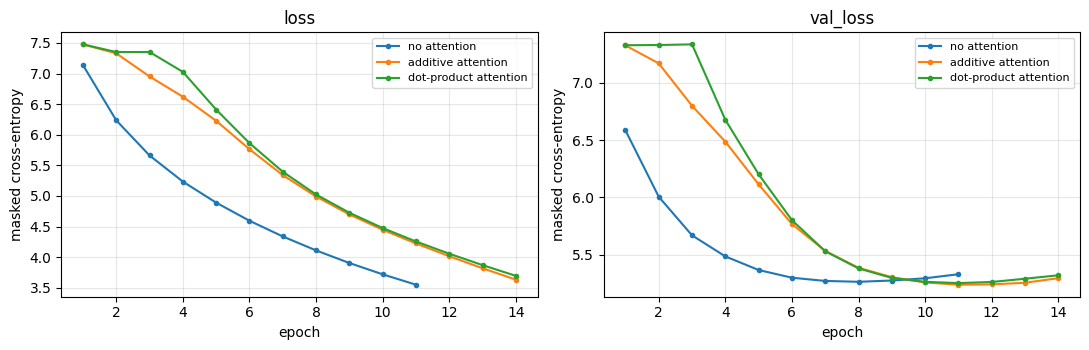

In [20]:
plt.figure(figsize=(11, 3.6))
for i, key in enumerate(("loss", "val_loss")):
    plt.subplot(1, 2, i + 1)
    for name in runs:
        h = runs[name]["history"][key]
        plt.plot(range(1, len(h) + 1), h, "o-", label=name, markersize=3)
    plt.title(key); plt.xlabel("epoch"); plt.ylabel("masked cross-entropy")
    plt.grid(alpha=.3); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "learning_curves.png", dpi=110); plt.show()

### What the models actually write

In [21]:
for i in range(3):
    print("=" * 100)
    print("ARTICLE  ", " ".join(test_df.article.iloc[i].split()[:45]), "...")
    print("REFERENCE", test_df.abstract.iloc[i])
    print("LEAD-1   ", " ".join(sentences(test_df.article.iloc[i])[:1]))
    for name in models:
        print(f"{name:9}", " ".join(runs[name]["predictions"][i].split()))
    print()

ARTICLE   Trong ngày 8-9/7 , các thí_sinh đăng_ký tuyển_sinh vào Học_viện Báo_chí & Tuyên_truyền ( AJC ) sẽ tham_gia bài thi năng_khiếu Báo_chí . Đây là năm thứ 5 liên_tiếp , AJC sử_dụng hình_thức thi năng_khiếu để tuyển_chọn sinh_viên nhóm ngành Báo_chí . Trong chiều 8/7 ...
REFERENCE Đề thi năng_khiếu Báo_chí của học_viện Báo_chí & Tuyên_truyền năm 2019 thử_thách sinh_viên với các kiến_thức xã_hội_đại_chúng bên cạnh đó lồng_ghép các sự_kiện nóng , nhân_vật có ảnh_hưởng như lối sống của người Việt , ...
LEAD-1    Trong ngày 8-9/7 , các thí_sinh đăng_ký tuyển_sinh vào Học_viện Báo_chí & Tuyên_truyền ( AJC ) sẽ tham_gia bài thi năng_khiếu Báo_chí .
no attention Ngày 26/5 , các trường đại_học , ĐH Quốc_gia TP. HCM đã có văn_bản gửi Bộ GD-ĐT và công_bố kết_quả thi THPT quốc_gia 2019 .
additive attention Sau khi nhận được nhiều ý_kiến về việc sử_dụng , nhiều phụ_huynh , sinh_viên Việt_Nam đã có những thông_tin về việc nhận được các trường đại_học , ngành , ngành và giáo_dục , cao_đẳng và g

## 8. Looking at the attention weights

The weights are the model's own explanation of where each output word came from. Two views:

- the full `(summary token × article position)` matrix, and
- attention averaged over output steps against article position, which shows whether the model
  discovered the lead bias the data measurement predicted.

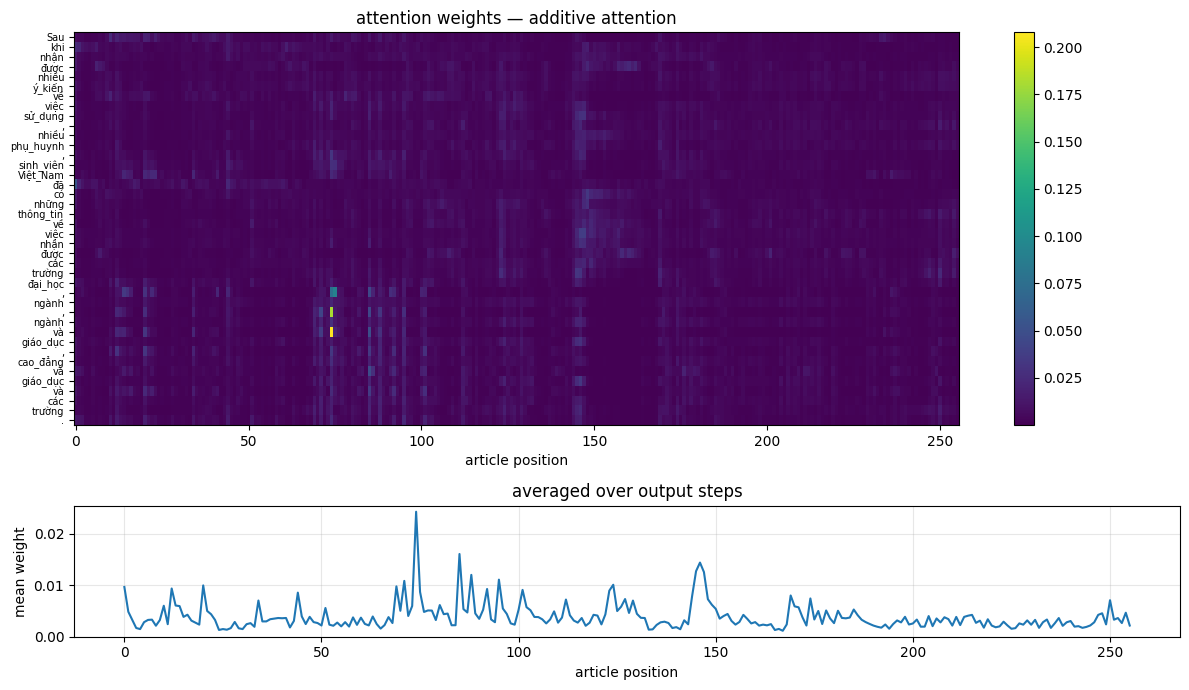

top attended article words per output token:

  Sau                <- Báo_chí(0.02), Tuyên_truyền(0.02), năng_khiếu(0.02), Báo_chí(0.02)
  khi                <- Trong(0.03), ngày(0.02), đề(0.02), gây(0.02)
  nhận               <- Vinasun(0.01), 8/7(0.01), Trong(0.01), gây(0.01)
  được               <- lối(0.02), của(0.02), gây(0.02), với(0.02)
  nhiều              <- Giao_thông(0.01), lỗi(0.01), tài_xế(0.01), Vinasun(0.01)
  ý_kiến             <- Trong(0.01), lỗi(0.01), chất_lượng(0.01), tự_luận(0.01)
  về                 <- đăng_ký(0.02), Báo_chí(0.02), Lịch_sử(0.02), Báo(0.02)
  việc               <- công_dân(0.02), Vinasun(0.02), taxi(0.02), phát_thanh(0.02)
  sử_dụng            <- Vinasun(0.03), taxi(0.03), tài_xế(0.02), công_dân(0.02)
  ,                  <- taxi(0.02), tài_xế(0.02), chủ_thể(0.02), phút(0.02)
  nhiều              <- Vinasun(0.02), taxi(0.02), tài_xế(0.02), nạn_nhân(0.02)
  phụ_huynh          <- tài_xế(0.02), Vinasun(0.02), taxi(0.02), Giao_thông(0.02)


In [22]:
def attention_for(model, article_ids):
    """Attention weights for one article, decoded greedily. (summary_len, article_len)."""
    article = tf.constant(article_ids[None, :])
    enc_out, state = model.encode(article)
    tokens = generate(model, article_ids[None, :])[0]
    ids = np.array([[BOS] + [stoi.get(t, UNK) for t in tokens]], np.int32)
    _, weights = model.decode(tf.constant(ids), enc_out, state, article != PAD)
    return np.array(weights)[0], tokens

attn_models = [n for n in models if n != "no attention"]
idx = 0
weights, tokens = (None, [])
if attn_models:
    name = attn_models[0]
    weights, tokens = attention_for(models[name], X_test[idx])

if not tokens:
    # An undertrained model can pick <eos> as its very first token, and there is nothing to plot.
    print("the model produced an empty summary for this article -- nothing to plot")
elif attn_models:
    article_tokens = test_df.article.iloc[idx].split()[:MAX_ARTICLE]
    n_show = min(len(article_tokens), MAX_ARTICLE)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                   gridspec_kw={"height_ratios": [3, 1]})
    im = ax1.imshow(weights[:len(tokens), :n_show], aspect="auto", cmap="viridis")
    ax1.set_yticks(range(len(tokens)))
    ax1.set_yticklabels(tokens, fontsize=7)
    ax1.set_xlabel("article position"); ax1.set_title(f"attention weights — {name}")
    fig.colorbar(im, ax=ax1)

    ax2.plot(weights[:len(tokens), :n_show].mean(0))
    ax2.set_xlabel("article position"); ax2.set_ylabel("mean weight")
    ax2.set_title("averaged over output steps"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(OUT / "attention.png", dpi=110); plt.show()

    print("top attended article words per output token:\n")
    for t, token in enumerate(tokens[:12]):
        top = weights[t, :n_show].argsort()[-4:][::-1]
        print(f"  {token:<18} <- " + ", ".join(f"{article_tokens[j]}({weights[t, j]:.2f})"
                                               for j in top))

In [23]:
metrics = {
    "scores": {k: {m: round(v, 4) for m, v in s.items()} for k, s in scores.items()},
    "runs": {k: {kk: vv for kk, vv in v.items() if kk != "history"} for k, v in runs.items()},
    "histories": {k: v["history"] for k, v in runs.items()},
    "config": {"n_train": N_TRAIN, "n_val": N_VAL, "n_test": N_TEST,
               "max_article": MAX_ARTICLE, "max_summary": MAX_SUMMARY, "vocab": VOCAB,
               "embed_dim": EMBED_DIM, "units": UNITS, "attn_units": ATTN_UNITS,
               "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LEARNING_RATE,
               "block_ngram": BLOCK_NGRAM, "mixed_precision": MIXED_PRECISION,
               "seed": SEED, "gpu": [g.name for g in gpus], "platform": where},
}
with open(OUT / "attention_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=1)

for name, model in models.items():
    model.save_weights(OUT / f"{name.replace(' ', '_')}.weights.h5")
print("saved to", OUT, ":", sorted(p.name for p in OUT.iterdir()))

saved to /kaggle/working : ['.virtual_documents', 'additive_attention.weights.h5', 'attention.png', 'attention_metrics.json', 'dot-product_attention.weights.h5', 'learning_curves.png', 'no_attention.weights.h5', 'vietnews_test.parquet', 'vietnews_train.parquet', 'vietnews_validation.parquet']


## 9. Reading these numbers honestly

- **The comparison that is valid** is model A against model B. Same data, same seed, same size,
  same number of epochs; one has attention and the other does not. That difference is the answer
  to the exercise.
- **The comparison against Lead-1 is not a fair fight, and is worth reporting anyway.** The
  baseline copies fluent human sentences; a model trained on 15% of the corpus for a few minutes
  writes from a 20k vocabulary it has seen a handful of times. If the baseline wins, that is the
  correct result to report, not a failure to hide — extractive lead baselines beat small
  abstractive models on news, which is exactly why news summarization papers always report it.
- **Nothing here is tuned.** One configuration, one seed, one run per model.